## PyPSA Beispiel 5

Sie haben die Aufgabe die Transformation der Stromversorgung für ein fiktives Land zu planen. Dabei sollen Sie in 10 Jahresschritten bis zum Jahr 2050 abschätzen, welche Erzeugungs- und Speicherkapazität benötigt wird. 
Im Jahr 2020 besteht der Erzeugungspark aus Kohle, Gas, Wind und PV. Die Kohle- und Gaskraftwerke sollen im Jahr 2030 und 2040 vom Netz gehen und durch PV, Wind, Batteriespeicher und H2-Kraftwerke ersetzt werden.



Hinweise:
* Zur Vereinfachung der Betrachtung geht es nur um den Stromsektor. 
* Sie können Annehmen, dass sich das Lastprofil nicht grundsätzlich ändert und für die Betrachtung hier in allen Zeiträumen gültig ist.
* Es soll keine Übertragung über Netze betrachtet werden. Betrachten Sie das System als einen Knoten für das gesamte Land
* Verwenden Sie eine Schleife um die zusätzlichen Komponenten hinzuzufügen, dies ist übersichtlicher

Systemskizze für ein Jahr:

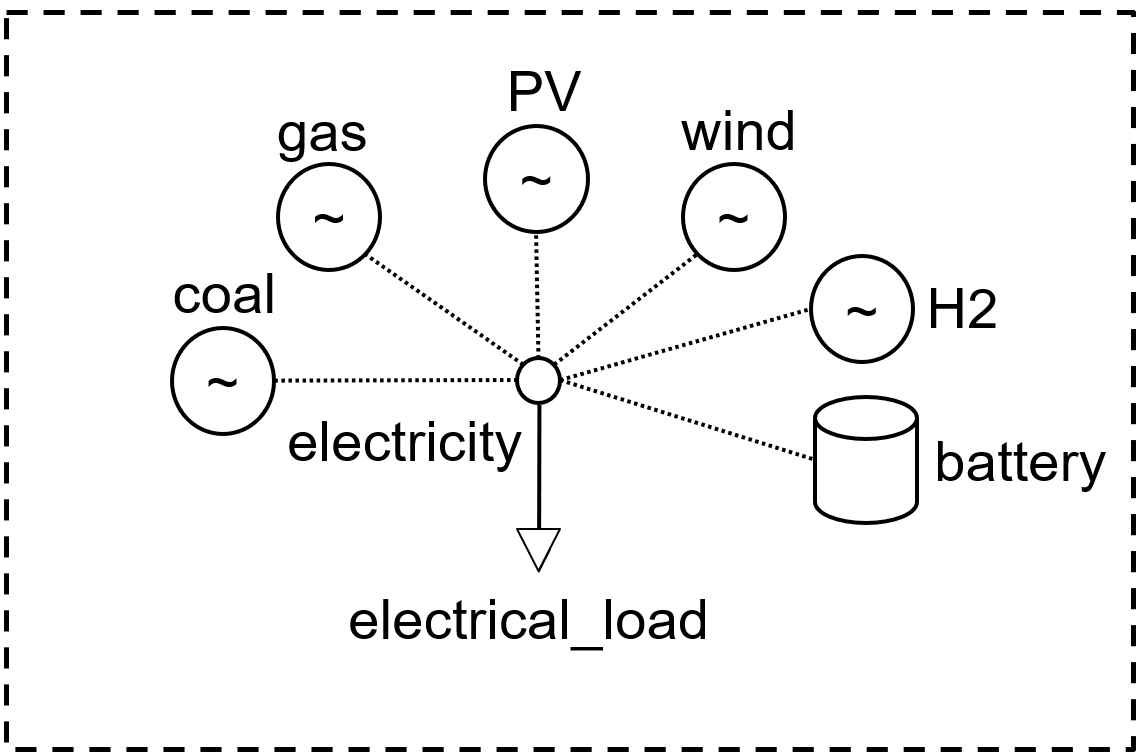

Importieren Sie die notwendigen Bibliotheken

Hier finden Sie zwei bereits definierte Funktionen die beim Umgang mit den Daten hilfreich sein können.

In [ ]:
def rescale_1h_to_xh(data_1h, freq):
    data_xh = data_1h
    data_xh.index = pd.date_range('01/01/2019', periods=8760,freq='h')
    data_xh = data_xh.resample('{}h'.format(str(freq))).mean()
    return data_xh

def concat_data_n_times(data_1_year, n):
    df_data = pd.DataFrame()
    for i in range(data_1_year.shape[1]):
        data = []
        for k in range(n):
            data += list(data_1_year.iloc[:,i])
        df_data[str(data_1_year.columns[i])] = data
    return df_data

Lesen Sie zu nächst die Daten aus der Dateie 'data_PyPSA_05.csv' ein. Die Daten liegen in stündlicher Auflösung für 1 Jahr vor. Ändern Sie die Auflösung auf 3h. Verbinden Sie den Datensatz, so dass Sie insgesamt Datenpunkte für vier Einjahreszeiträume haben.

Die oben definierten Funktionen können dabei helfen.

Folgende Annahmen sollen im Modell berücksichtigt werden.

In [ ]:
# Assumptions

# installed power https://energy-charts.info/charts/installed_power

p_nom_coal = 43740 # MW 
p_nom_gas = 35540 # MW 
p_nom_wind = 70000 # MW 
p_nom_pv = 54400 #MW 

# marginal cost
marginal_cost_coal = 28 # €/MWh_el  2017_Praxisbuch_Energiewirtschaft
marginal_cost_gas = 43.722 / 0.4 # €/MWh_el https://www.eex.com/de/marktdaten/erdgas/indizes
marginal_cost_h2 = 60 / 0.4 # €/MWh_el


co2_emissions_coal = 867 #kg/MWh for Hard coal https://www.volker-quaschning.de/datserv/CO2-spez/index_e.php
co2_emissions_gas = 358 #kg/MWh https://www.volker-quaschning.de/datserv/CO2-spez/index_e.php

build_year_fossil = 2010
lifetime_coal = 20
lifetime_gas = 30
lifetime_other = 20

# efficiency
efficiency_coal = 0.35
efficiency_gas = 0.55
efficiency_storage = 0.9 #roundtrip


# capital cost
capital_cost_pv = 87500 # €/MW as annuity
capital_cost_battery = 60000 #€/MWh as annuity
capital_cost_wind = 70000 # €/MWp as annuity
capital_cost_fuelcell = 115000 #€/MW as annuity

# maximum installable capacity in 10 years
p_nom_max_pv = 200000 # Annahme 
p_nom_max_fuelcell = 10000 # Annahme
p_nom_max_wind = 900000 # Annahme

Bauen Sie als Nächstes das Netzwerk auf. Einige Code Abschnitte sind bereits vorhanden. Für den Rest helfen die bereist definierten Abschnitte.

In [ ]:
# Network and temporal definition 


# Code from https://pypsa.readthedocs.io/en/latest/examples/multi-investment-optimisation.html
snapshots = pd.DatetimeIndex([])
for year in years:
    period = pd.date_range(
        start="{}-01-01 00:00".format(year),
        freq="{}h".format(str(freq)),
        periods=int(8760 / freq),
    )
    snapshots = snapshots.append(period)
    
network.snapshots = pd.MultiIndex.from_arrays([snapshots.year, snapshots])
network.investment_periods = years

# Code from https://pypsa.readthedocs.io/en/latest/examples/multi-investment-optimisation.html
network.investment_period_weightings["years"] = list(np.diff(years)) + [10]

r = 0.02
T = 0
for period, nyears in network.investment_period_weightings.years.items():
    discounts = [(1 / (1 + r) ** t) for t in range(T, T + nyears)]
    network.investment_period_weightings.at[period, "objective"] = sum(discounts)
    T += nyears
network.investment_period_weightings

network.snapshot_weightings[network.snapshot_weightings.columns] = float(freq)


#-----COMPONENTS-----


Überprüfen Sie mit n.generators, ob die gewünschten Generatoren hinzugefügt wurden.

Optimieren Sie Netzwerk mit: 

network.optimize(solver_name = 'gurobi', multi_investment_periods=True, threads = 1)

Lassen Sie sich die Generatorleistungen als Plot ausgeben. Verwenden die das Attribut alpha des Plot Befehls im die Graphen transparenter zu machen.

Der folgende Code zeigt die erzeugte Energie über den Investitionszeitraum.

In [ ]:
#Code from https://pypsa.readthedocs.io/en/latest/examples/multi-investment-optimisation.html
df = network.generators_t.p.groupby(level=0).sum()
df.plot.bar(
    stacked=True,
    edgecolor="white",
    width=1,
    ylabel="Generation",
    xlabel="Investment Period",
    rot=0,
    figsize=(10, 5),
)

Der folgende Code zeigt die installierten Leistungen, über den Investitionszeitraum.

In [ ]:
# Code from https://pypsa.readthedocs.io/en/latest/examples/multi-investment-optimisation.html

c = "Generator"
df = pd.concat(
    {
        period: network.get_active_assets(c, period) * network.df(c).p_nom_opt
        for period in network.investment_periods
    },
    axis=1,
)
df.T.plot.bar(
    stacked=True,
    edgecolor="white",
    width=1,
    ylabel="Capacity",
    xlabel="Investment Period",
    rot=0,
    figsize=(10, 5),
)
plt.tight_layout()